# Wrap-Up zur Datenanalyse in pandas

- Daten laden
- Daten exportieren
- Daten visualisieren
- Unsupervised learning mit sklearn

In [1]:
from pandas import read_csv
from matplotlib import pyplot as plt
from os.path import isdir
from os import makedirs
from seaborn import pairplot, clustermap, heatmap
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

## Daten laden

Damit wir Daten laden können, müssen wir diese zuerst in Colab hochladen!!!

!pip install --upgrade pip
!pip install -r ../requirements.txt

In [2]:
df = read_csv("../data/titanic.csv")

## Data Exploration

In [3]:
# Überblicksdarstellung unseres Dataframes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Einfache describtive Ausgabe
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head(2) # und df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


## Data visualization

<Axes: ylabel='Frequency'>

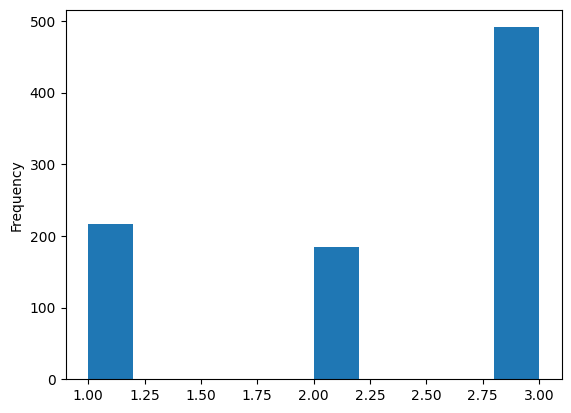

In [6]:
df["Pclass"].plot(kind="hist")

<Axes: ylabel='Pclass'>

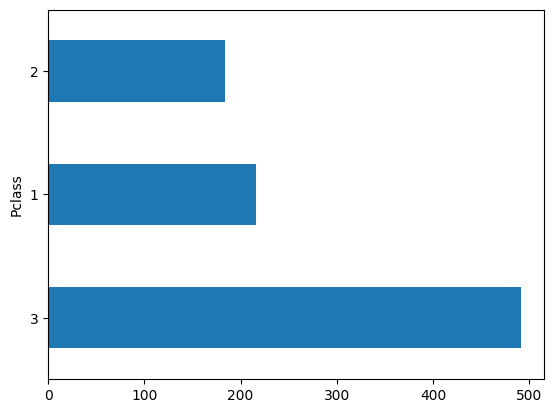

In [7]:
df['Pclass'].value_counts().plot(kind="barh")

In [ ]:
df['Age'].value_counts().sort_index().plot(kind="barh", figsize=(6, 20))
plt.title("Distribution of Age")
plt.xlabel("Number of persons")
plt.ylabel("Age group")
plt.savefig("../img/age_plot.png")

<Axes: xlabel='Sex'>

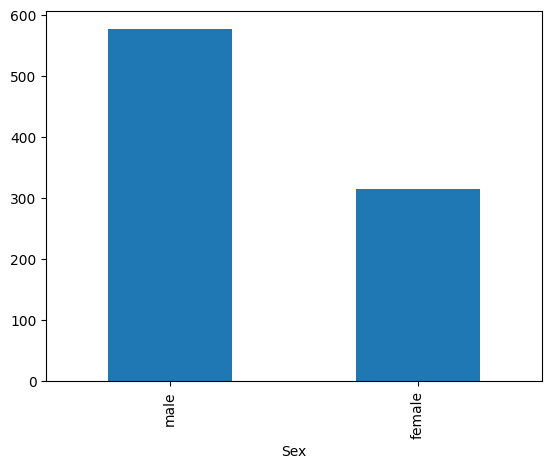

In [ ]:
df['Sex'].value_counts().plot(kind="bar")

<Axes: ylabel='Ticket'>

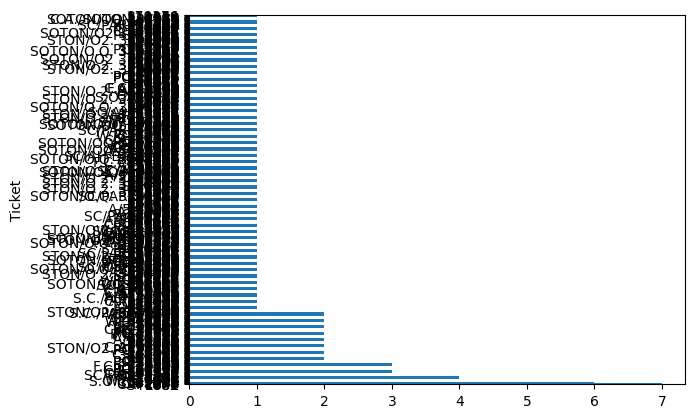

In [ ]:
df['Ticket'].value_counts().plot(kind="barh")

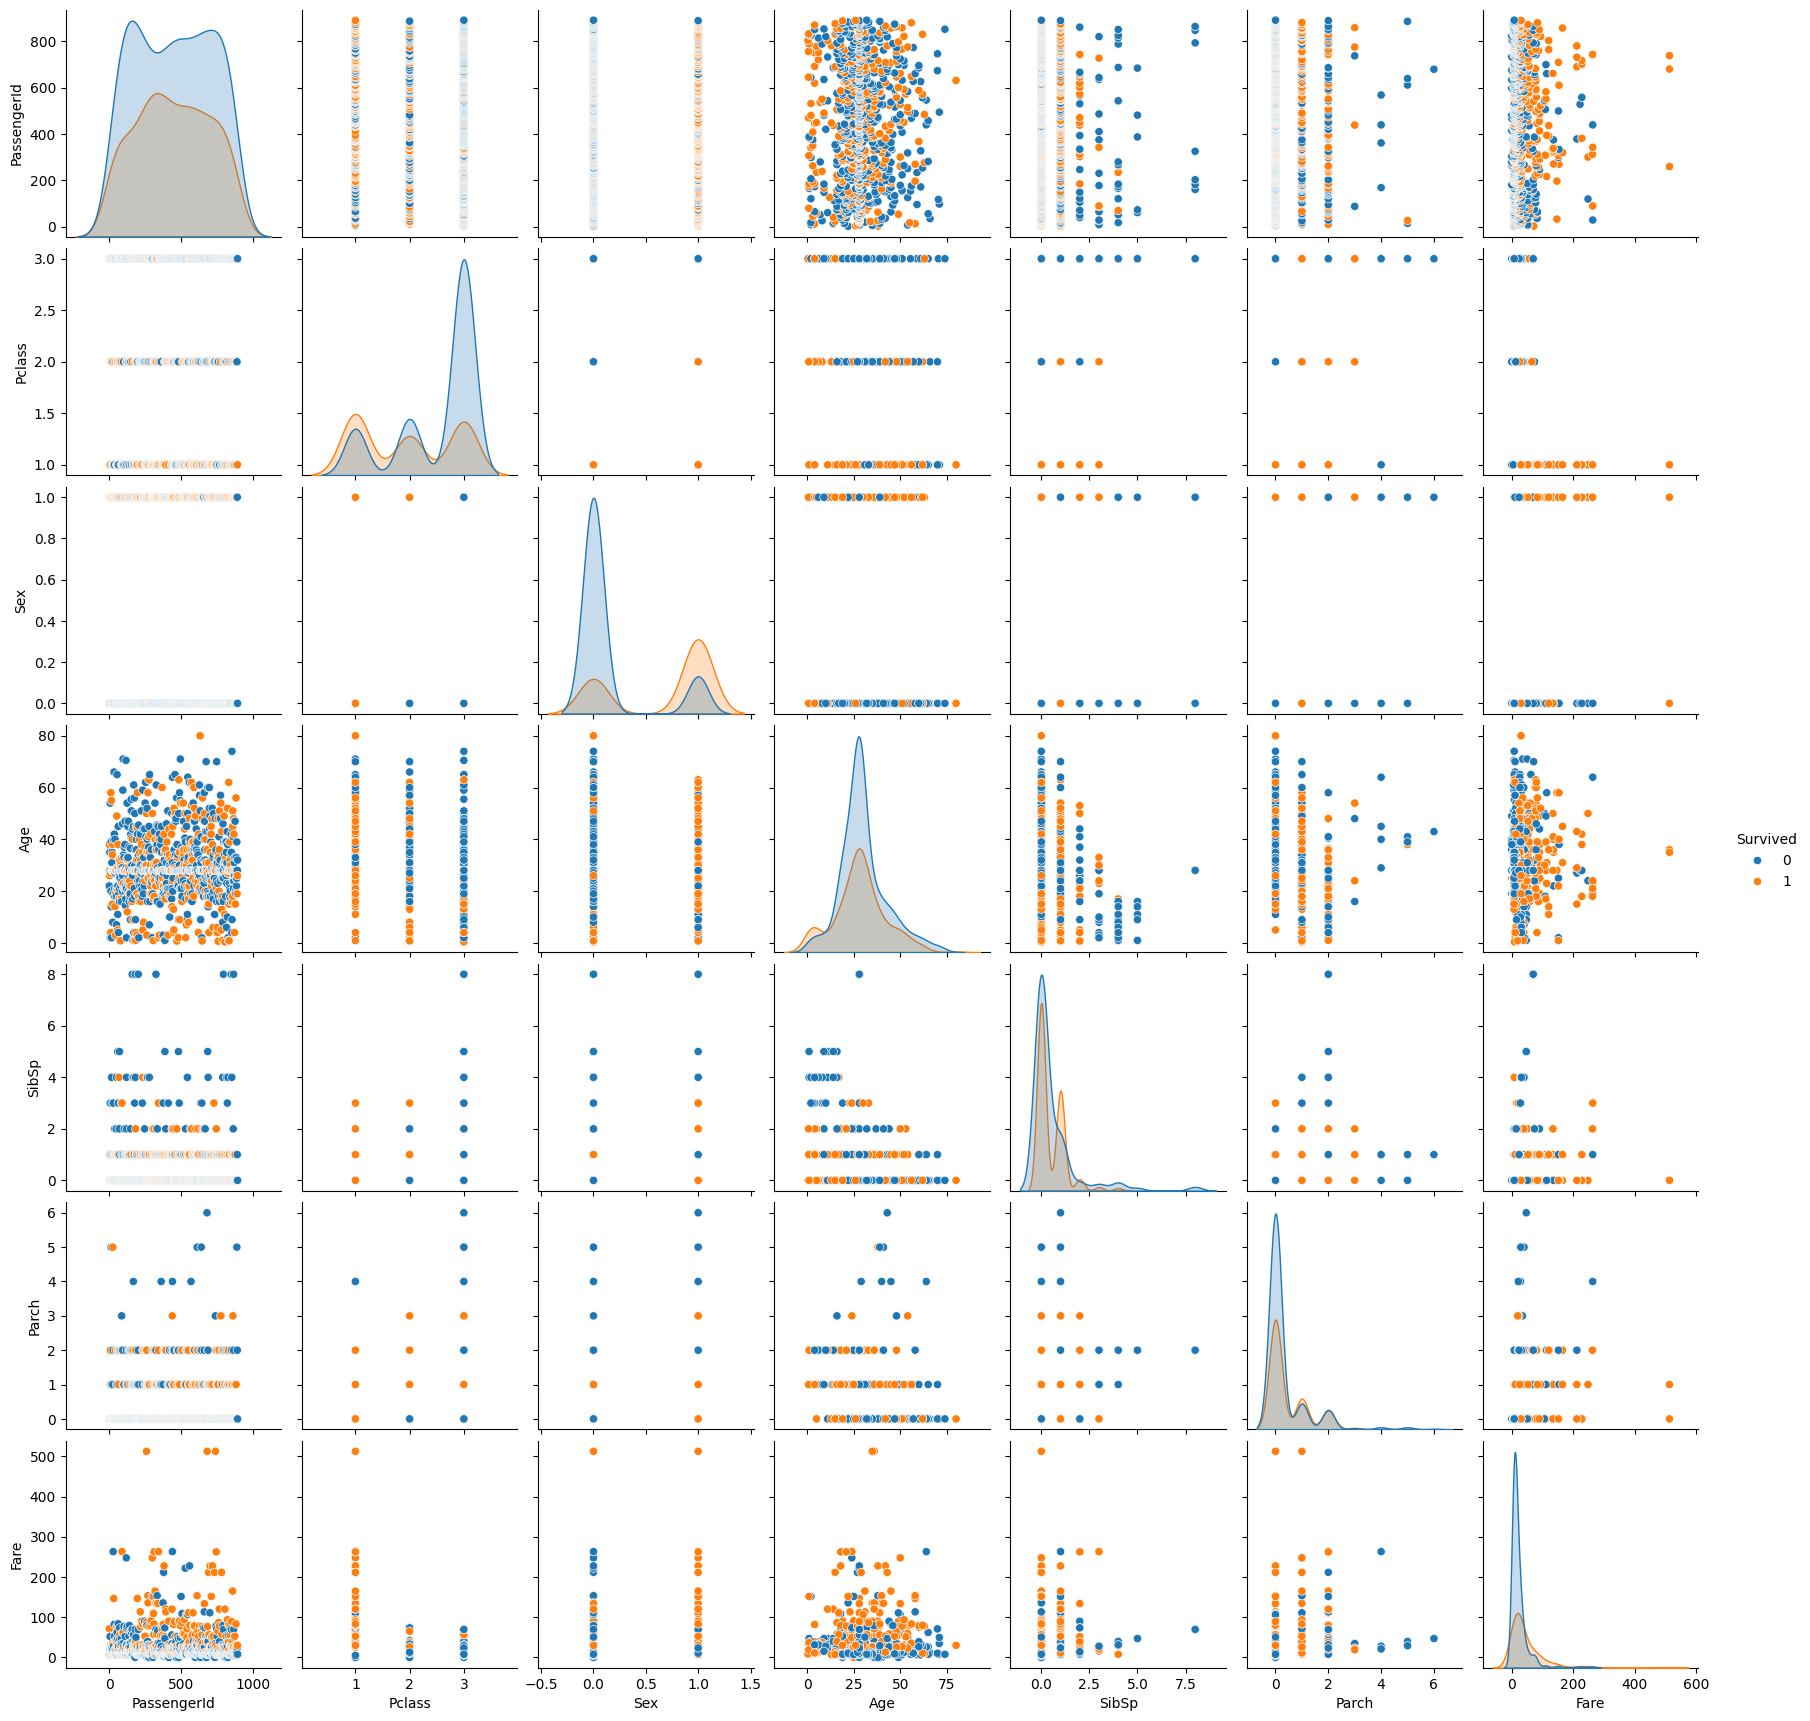

In [ ]:
# Schneller Überblicksplot über alle NUMMERISCHEN Merkmale
pairplot(df, hue="Survived")
plt.savefig("../img/pairplot.png")

# Herausgreifen von bestimmten Features, falls unser DataFrame ansonsten zu groß würde
# Man kann mehrere machen

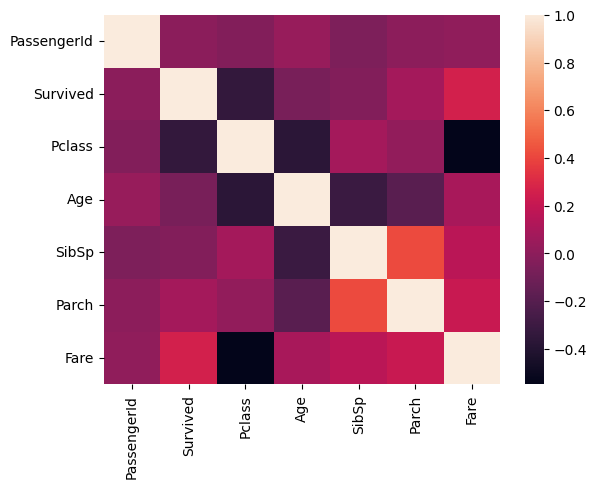

In [ ]:
heatmap(df.select_dtypes(include="number").corr())
plt.savefig("../img/heatmap.png")

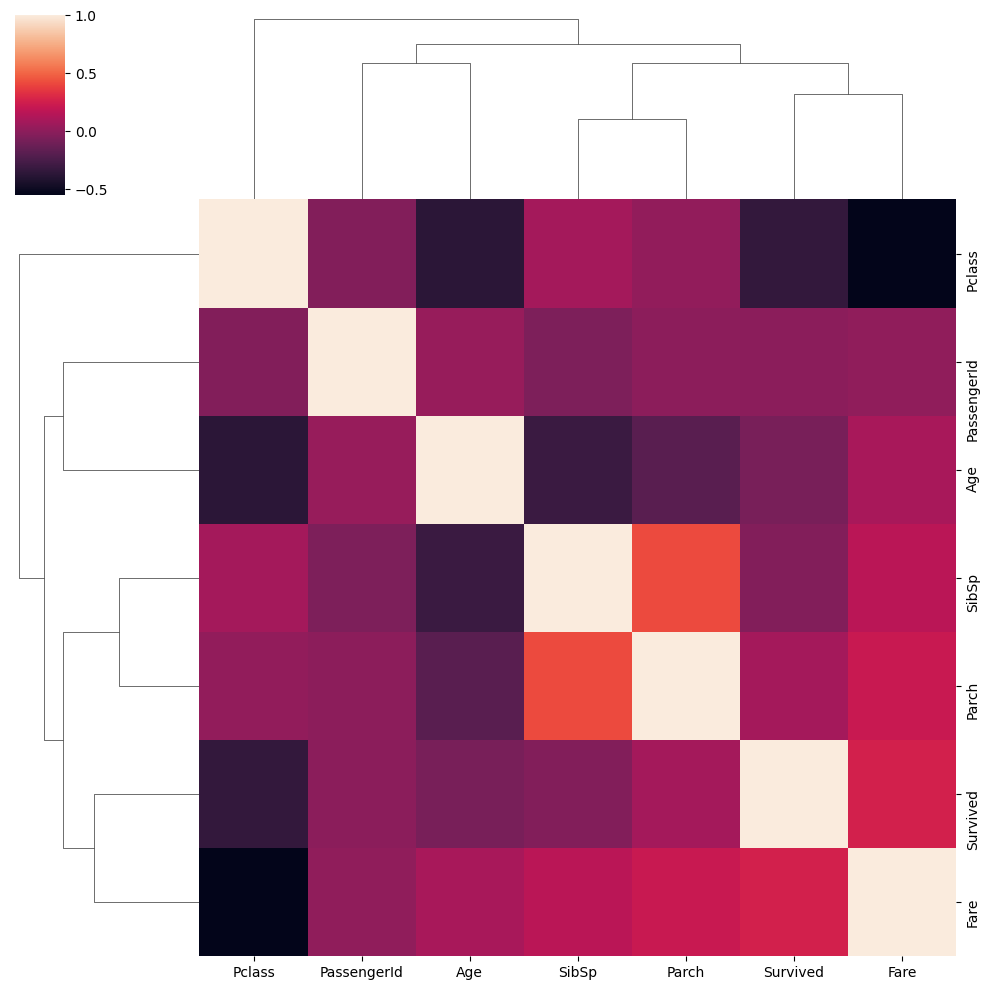

In [ ]:
clustermap(df.select_dtypes(include="number").corr())
plt.savefig("../img/clustermap.png")

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
# Umwandlung der Spalte Sex in eine nummerische Spalte
mapping_dictionary = {"male": 0, "female": 1}
df["Sex"] = df["Sex"].map(mapping_dictionary)

In [ ]:
# Umgang mit fehlenden Werten (Achtung: Hier gibt es kein richtig oder falsch)
# df = df.dropna()
# df["Age"] = df["Age"].fillna(-999)
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df.select_dtypes(include="number")

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833
2,3,1,3,1,26.0,0,0,7.9250
3,4,1,1,1,35.0,1,0,53.1000
4,5,0,3,0,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000
887,888,1,1,1,19.0,0,0,30.0000
888,889,0,3,1,28.0,1,2,23.4500
889,890,1,1,0,26.0,0,0,30.0000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


### Preparate for ML

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [ ]:
targed = 'Survived'
used_columns = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
       ]

In [ ]:
X = df[used_columns]

### Unsupervised Learning

In [ ]:
hierarchical_engine = AgglomerativeClustering(n_clusters=2)
clusters = hierarchical_engine.fit_predict(X)

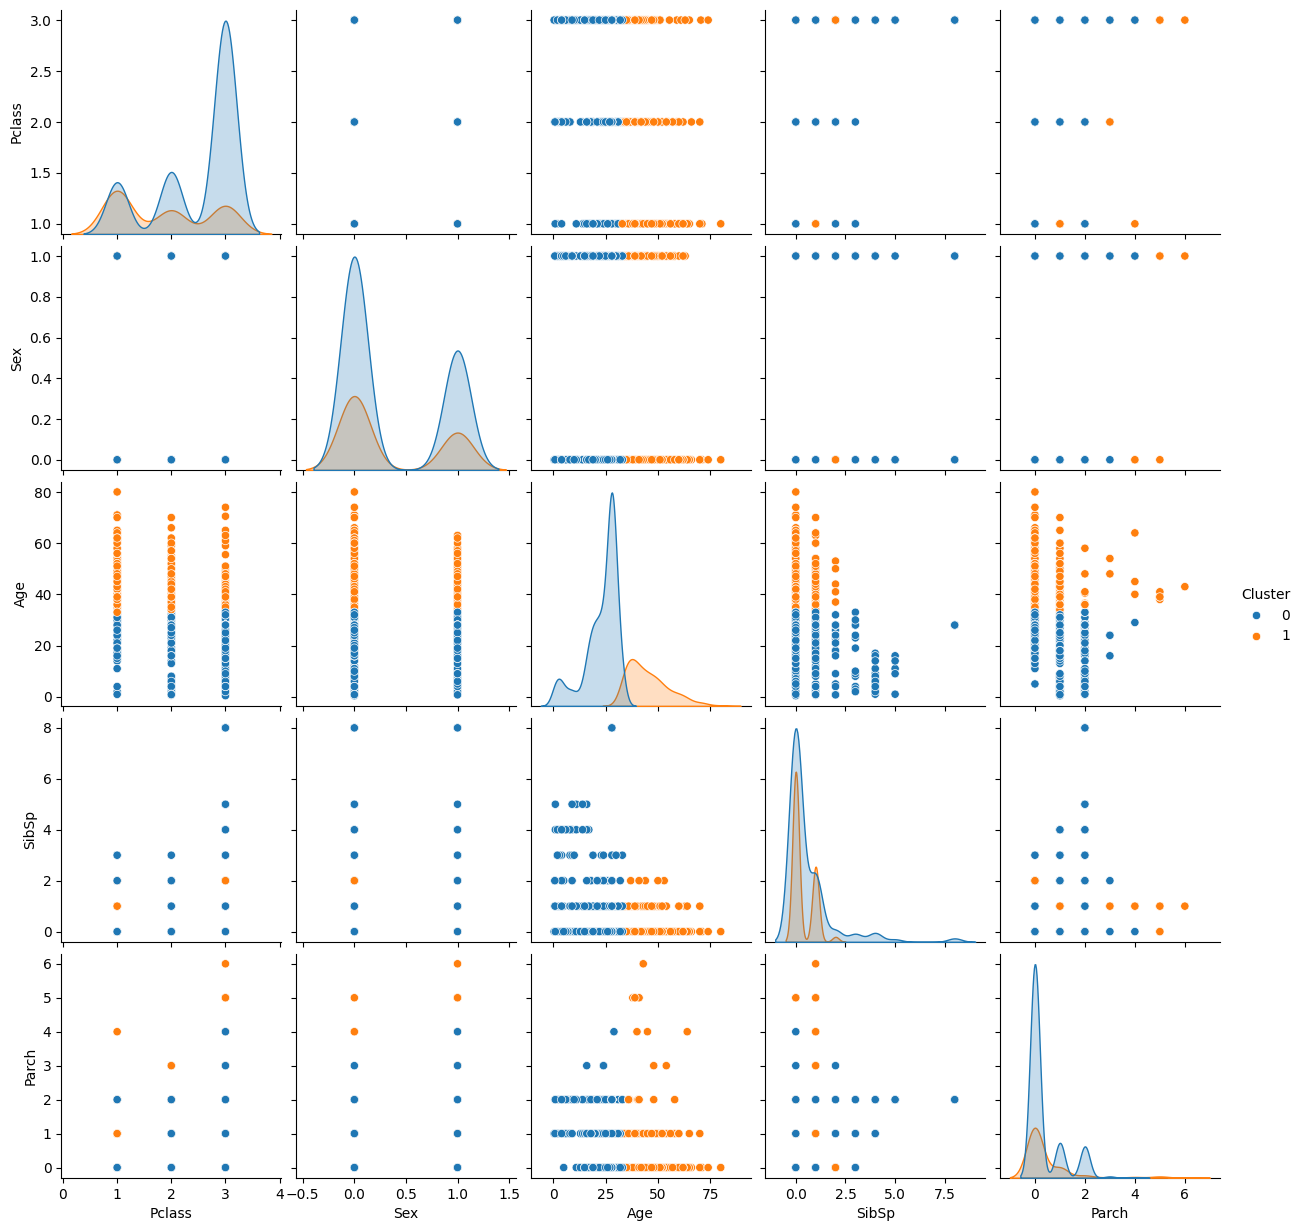

In [ ]:
result = X.copy()
result["Cluster"] = clusters
pairplot(X, hue="Cluster")

<Axes: xlabel='Age', ylabel='Pclass'>

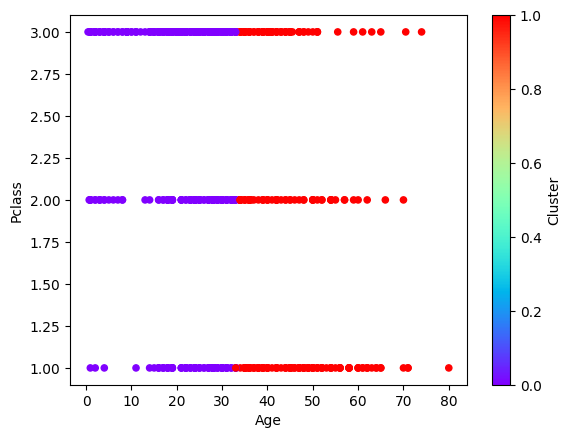

In [ ]:
result.plot(kind="scatter", x="Age", y="Pclass", c="Cluster", colormap="rainbow")

In [ ]:
hierarchical_engine.fit(X)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",2
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [ ]:
from scipy.cluster import hierarchy

{'icoord': [[35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [15.0, 15.0, 32.5, 32.5],
  [5.0, 5.0, 23.75, 23.75],
  [75.0, 75.0, 85.0, 85.0],
  [65.0, 65.0, 80.0, 80.0],
  [55.0, 55.0, 72.5, 72.5],
  [14.375, 14.375, 63.75, 63.75],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [125.0, 125.0, 135.0, 135.0],
  [145.0, 145.0, 155.0, 155.0],
  [175.0, 175.0, 185.0, 185.0],
  [165.0, 165.0, 180.0, 180.0],
  [150.0, 150.0, 172.5, 172.5],
  [130.0, 130.0, 161.25, 161.25],
  [102.5, 102.5, 145.625, 145.625],
  [195.0, 195.0, 205.0, 205.0],
  [215.0, 215.0, 225.0, 225.0],
  [200.0, 200.0, 220.0, 220.0],
  [124.0625, 124.0625, 210.0, 210.0],
  [39.0625, 39.0625, 167.03125, 167.03125],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [235.0, 235.0, 252.5, 252.5],
  [305.0, 305.0, 315.0, 315.0],
  [295.0, 295.0, 310.0, 310.0],
  [285.0, 285.0, 302.5, 302.5],
  [275.0, 275.0, 293.75, 293.75],
  [243.75, 243.75, 284.375, 284.375],
  [335.0, 335.0, 345.0, 34

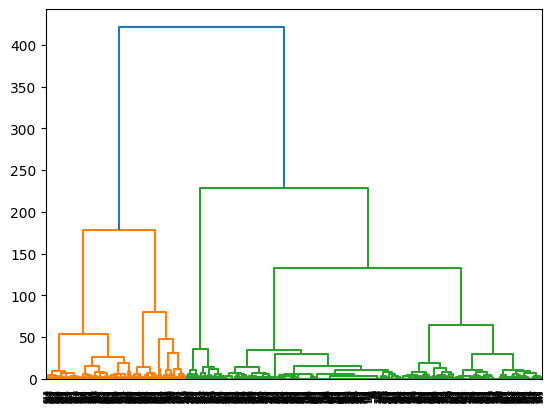

In [ ]:
distance_matrix = hierarchy.linkage(X, method="ward")
hierarchy.dendrogram(distance_matrix)

In [ ]:
kmeans_engine = KMeans(n_clusters=2)
kmeans_engine.fit_predict(X)

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,

In [ ]:
dbscan_engine = DBSCAN(eps=0.5, min_samples=5)
dbscan_engine.fit_predict(X)

array([-1, -1, -1, -1,  0,  1, -1, -1, -1, -1, -1, -1,  2, -1, -1, -1, -1,
        3, -1,  4, -1, -1, -1,  5, -1, -1,  1, -1,  4,  1, -1,  6,  4, -1,
       -1, -1,  1,  2, -1, -1, -1, -1,  1, -1, -1,  1,  7,  4, -1, -1, -1,
        2, -1, -1, -1,  5, -1,  1, -1, -1,  8, -1, -1, -1,  5, -1, -1,  9,
       -1, -1, -1, -1, -1, -1, 10, 11,  1,  1, -1, 23,  8,  1,  4,  5, -1,
       -1, -1,  1, -1, 11,  1,  2, -1, -1, -1,  1, -1, -1, -1, -1,  4,  1,
       -1, 12, -1,  1, -1,  1, -1, 13, -1, -1,  8, -1, -1,  2, -1, -1, -1,
       -1, -1,  1, -1, -1, -1, -1,  1, 11, -1, -1, 12,  2, -1, -1, -1, 14,
       -1, -1, 15, -1, -1, 16, -1,  9, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1,  1, -1, -1, 17,  1, -1, -1, -1, 18, -1, -1, -1, -1, -1,  5,  1,
       -1, -1, -1,  2, -1, -1, -1, -1, -1, -1, -1,  3, -1, -1, -1,  5, 13,
       22, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  4, -1,  1, -1,  0, -1,
       19, -1, -1, 18, -1, -1, 11, -1,  8, -1,  7, -1, -1, -1, -1, -1, 15,
       -1, -1,  1, -1,  8